In [49]:
%pip install numpy pandas seaborn torch torchvision scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../house-prices-advanced-regression-techniques/train.csv")

X = df["GrLivArea"].values.reshape(-1, 1)
y = df["SalePrice"].values.reshape(-1, 1)

print(X.shape, y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

(1460, 1) (1460, 1)


# Scratch

In [52]:
# @title 1.2 - build linear model + learning update (gradient descent + learning rate) => Gradient Descent
class UpdatedLinearRegressionScratch:
    """
    Custom implementation of linear regression using gradient descent.
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        """
        Fits the linear regression model to the given data using gradient descent.
        Args:
            X: A numpy array of shape (n_samples, n_features) representing the input data.
            y: A numpy array of shape (n_samples,) representing the target values.
        """
        # Initialize coefficients (slope) and intercept to zero or random small values
        self.coef_ = np.dot(np.linalg.inv(np.dot(X.T, X)), np.dot(X.T, y))
        self.intercept_ = np.mean(y - np.dot(X, self.coef_))

        m = len(y)  # number of training examples

        for _ in range(self.n_iterations):
            # Calculate the predictions
            y_pred = self.predict(X)

            # Compute the residuals (errors)
            # mse cost
            error = y_pred - y

            # error = (1/m)*(y_pred - y)**2  # Note: just difference loss = the distance of prediction to ground truth, not a practical loss, like MSE, MAE

            # Calculate the gradient for intercept (slope) and coefficients (slope)
            intercept_gradient = (2/m) * np.sum(error)
            coef_gradient = (2/m) * np.dot(X.T, error)

            # Update the parameters using the gradients
            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient

    def predict(self, X):
        """
        Predicts the target values for new data.
        Args:
            X: A numpy array of shape (n_samples, n_features) representing the new input data.
        Returns:
            A numpy array of shape (n_samples,) representing the predicted target values.
        """
        return np.dot(X, self.coef_) + self.intercept_

In [53]:
lr = 0.01
n_iter = 1000
lin_reg_updated = UpdatedLinearRegressionScratch(learning_rate=lr, n_iterations=n_iter)
lin_reg_updated.fit(X_scaled_train, y_train)

print(f"Intercept : {lin_reg_updated.intercept_}\nCoef : {lin_reg_updated.coef_[0][0]}")

Intercept : 181441.5419520548
Coef : 53725.54630631854


In [54]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = lin_reg_updated.predict(X_scaled_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 3418946311.180806
R^2 Score: 0.5542632452871117


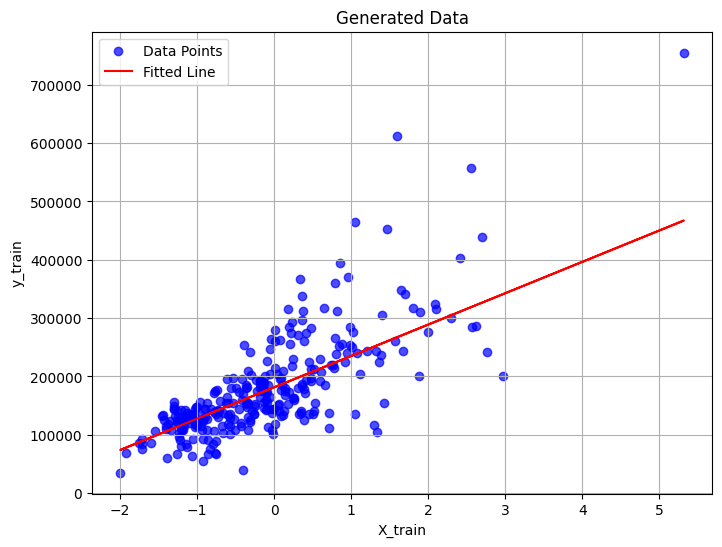

In [56]:
plt.figure(figsize=(8, 6))
plt.title("Generated Data")
plt.scatter(X_scaled_test, y_test, color="blue", alpha=0.7, label="Data Points")
plt.xlabel("X_train")
plt.ylabel("y_train")
plt.plot(X_scaled_test, y_pred, color="red", label="Fitted Line")
plt.legend()
plt.grid(True)
plt.show()

# Sci-kit Learn

In [58]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_scaled_train, y_train)
y_pred = model.predict(X_scaled_test)

print(f"Intercept : {model.intercept_[0]}\nCoef : {model.coef_[0][0]}")

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Intercept : 181441.5419520548
Coef : 53725.546306318574
Mean Squared Error: 3418946311.1808057
R^2 Score: 0.5542632452871118
